# Loan Approval Prediction

## Phase 6 – Model Evaluation

**Name:** Abdur Rafay Hassan Baloch  
**Problem Type:** Binary Classification  
**Model:** Logistic Regression  
**Target Variable:** Loan_Status

## 1. Load Dataset and Trained Model

The cleaned dataset and previously trained Logistic Regression pipeline are loaded for evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv("cleaned_loan_approval_dataset.csv")
model = joblib.load("loan_approval_logistic_model.pkl")

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("DATA AND MODEL LOADING")
print("-" * 45)
print("Dataset Shape:", df.shape)
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))
print("Model Loaded Successfully")
print("Test Predictions Generated Successfully")
print("Prediction Probabilities Generated Successfully")

DATA AND MODEL LOADING
---------------------------------------------
Dataset Shape: (614, 14)
Training Records: 491
Testing Records: 123
Model Loaded Successfully
Test Predictions Generated Successfully
Prediction Probabilities Generated Successfully


## 2. All Classification Evaluation Metrics

The model is evaluated using accuracy, precision, recall, F1-score, specificity and ROC-AUC.

In [2]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

metrics_table = pd.DataFrame({
    "Evaluation Metric": [
        "Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "F1-Score",
        "Specificity",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        roc_auc
    ],
    "Percentage": [
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        f"{specificity * 100:.2f}%",
        f"{roc_auc * 100:.2f}%"
    ]
})

print("ALL MODEL EVALUATION METRICS")
print("-" * 50)

metrics_table[["Evaluation Metric", "Percentage"]]

ALL MODEL EVALUATION METRICS
--------------------------------------------------


,Evaluation Metric,Percentage
0,Accuracy,85.37%
1,Precision,83.84%
2,Recall (Sensitivity),97.65%
3,F1-Score,90.22%
4,Specificity,57.89%
5,ROC-AUC,84.89%


## 3. Confusion Matrix

The confusion matrix shows correct and incorrect predictions for rejected and approved loan applications.

CONFUSION MATRIX ANALYSIS
--------------------------------------------------
True Negatives  (Correctly Rejected): 22
False Positives (Incorrectly Approved): 16
False Negatives (Incorrectly Rejected): 2
True Positives  (Correctly Approved): 83
Total Test Predictions: 123
Correct Predictions: 105
Incorrect Predictions: 18


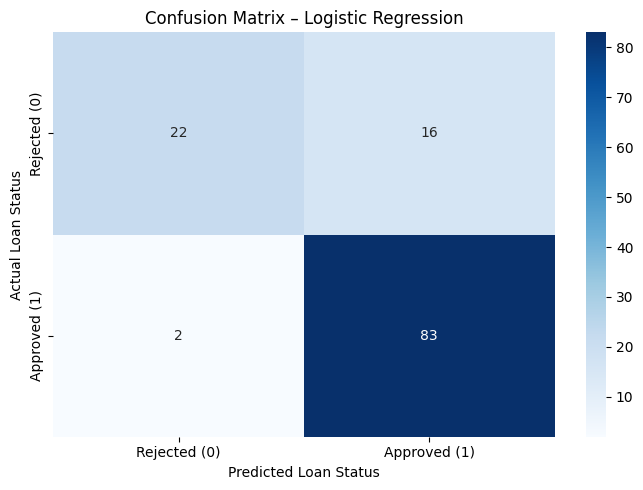

In [3]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX ANALYSIS")
print("-" * 50)
print("True Negatives  (Correctly Rejected):", tn)
print("False Positives (Incorrectly Approved):", fp)
print("False Negatives (Incorrectly Rejected):", fn)
print("True Positives  (Correctly Approved):", tp)
print("Total Test Predictions:", len(y_test))
print("Correct Predictions:", tn + tp)
print("Incorrect Predictions:", fp + fn)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected (0)", "Approved (1)"],
    yticklabels=["Rejected (0)", "Approved (1)"]
)

plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted Loan Status")
plt.ylabel("Actual Loan Status")
plt.tight_layout()
plt.show()

## 4. Classification Report

The classification report provides precision, recall, F1-score and support for both loan-status classes.

In [4]:
print("CLASSIFICATION REPORT")
print("=" * 65)
print("Class 0 = Loan Rejected")
print("Class 1 = Loan Approved")
print("=" * 65)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Rejected (0)", "Approved (1)"],
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT
Class 0 = Loan Rejected
Class 1 = Loan Approved
              precision    recall  f1-score   support

Rejected (0)     0.9167    0.5789    0.7097        38
Approved (1)     0.8384    0.9765    0.9022        85

    accuracy                         0.8537       123
   macro avg     0.8775    0.7777    0.8059       123
weighted avg     0.8626    0.8537    0.8427       123



## 5. ROC-AUC Analysis

The ROC curve evaluates the model's ability to distinguish between approved and rejected loan applications at different decision thresholds.

ROC-AUC ANALYSIS
---------------------------------------------
ROC-AUC Score: 0.8489
ROC-AUC Percentage: 84.89%
Number of Thresholds Evaluated: 33


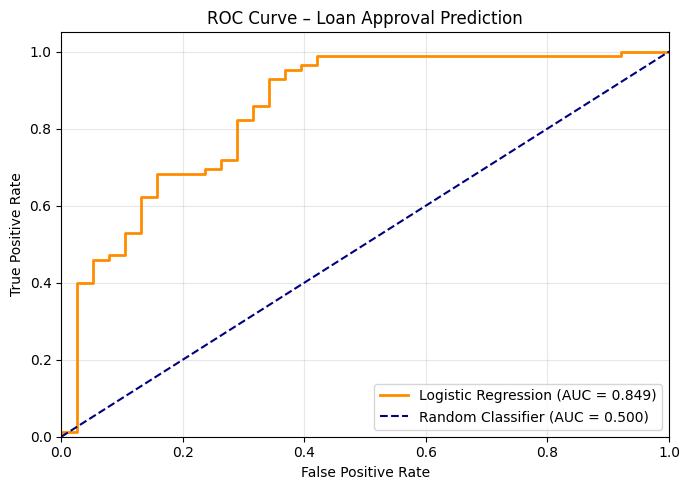

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

print("ROC-AUC ANALYSIS")
print("-" * 45)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"ROC-AUC Percentage: {roc_auc * 100:.2f}%")
print("Number of Thresholds Evaluated:", len(thresholds))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    linestyle="--",
    label="Random Classifier (AUC = 0.500)"
)

plt.title("ROC Curve – Loan Approval Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Precision and Recall Tradeoff

Model performance is compared at different probability decision thresholds.

In [6]:
threshold_results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_predictions = (
        y_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Decision Threshold": f"{threshold:.0%}",
        "Accuracy": f"{accuracy_score(y_test, threshold_predictions) * 100:.2f}%",
        "Precision": f"{precision_score(y_test, threshold_predictions, zero_division=0) * 100:.2f}%",
        "Recall": f"{recall_score(y_test, threshold_predictions, zero_division=0) * 100:.2f}%",
        "F1-Score": f"{f1_score(y_test, threshold_predictions, zero_division=0) * 100:.2f}%"
    })

threshold_table = pd.DataFrame(threshold_results)

print("PRECISION AND RECALL TRADEOFF")
print("-" * 55)
print("Lower threshold: More approvals and higher recall.")
print("Higher threshold: Stricter approvals and usually higher precision.")
print("Default Logistic Regression threshold: 50%")
print()

threshold_table

PRECISION AND RECALL TRADEOFF
-------------------------------------------------------
Lower threshold: More approvals and higher recall.
Higher threshold: Stricter approvals and usually higher precision.
Default Logistic Regression threshold: 50%



,Decision Threshold,Accuracy,Precision,Recall,F1-Score
0,30%,85.37%,83.17%,98.82%,90.32%
1,40%,86.18%,84.00%,98.82%,90.81%
2,50%,85.37%,83.84%,97.65%,90.22%
3,60%,84.55%,84.38%,95.29%,89.50%
4,70%,78.05%,85.37%,82.35%,83.83%


## 7. Final Model Analysis

The final analysis summarizes the model's performance, generalization and prediction errors.

In [7]:
training_accuracy = model.score(X_train, y_train)
testing_accuracy = model.score(X_test, y_test)
accuracy_difference = abs(training_accuracy - testing_accuracy)

print("FINAL LOGISTIC REGRESSION MODEL ANALYSIS")
print("=" * 65)
print(f"Training Accuracy: {training_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {testing_accuracy * 100:.2f}%")
print(f"Train/Test Accuracy Difference: {accuracy_difference * 100:.2f}%")
print()
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-Score: {f1 * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"ROC-AUC: {roc_auc * 100:.2f}%")
print()
print("Correctly Rejected Applications:", tn)
print("Incorrectly Approved Applications:", fp)
print("Incorrectly Rejected Applications:", fn)
print("Correctly Approved Applications:", tp)
print()

if accuracy_difference <= 0.05:
    print("Generalization Analysis: The model shows good generalization.")
else:
    print("Generalization Analysis: The model may require further improvement.")

if recall > precision:
    print("Tradeoff Analysis: Recall is higher than precision.")
    print("The model identifies most approved applications but produces more false approvals.")
elif precision > recall:
    print("Tradeoff Analysis: Precision is higher than recall.")
    print("Approval predictions are stricter, but some approved applications may be missed.")
else:
    print("Tradeoff Analysis: Precision and recall are balanced.")

print()
print("Overall Conclusion:")
print("The Logistic Regression model was evaluated successfully.")
print("Credit history helps the model identify loan approval patterns.")
print("Further improvement may be possible through feature engineering,")
print("class balancing, threshold tuning and model comparison.")

FINAL LOGISTIC REGRESSION MODEL ANALYSIS
Training Accuracy: 80.04%
Testing Accuracy: 85.37%
Train/Test Accuracy Difference: 5.33%

Precision: 83.84%
Recall: 97.65%
F1-Score: 90.22%
Specificity: 57.89%
ROC-AUC: 84.89%

Correctly Rejected Applications: 22
Incorrectly Approved Applications: 16
Incorrectly Rejected Applications: 2
Correctly Approved Applications: 83

Generalization Analysis: The model may require further improvement.
Tradeoff Analysis: Recall is higher than precision.
The model identifies most approved applications but produces more false approvals.

Overall Conclusion:
The Logistic Regression model was evaluated successfully.
Credit history helps the model identify loan approval patterns.
Further improvement may be possible through feature engineering,
class balancing, threshold tuning and model comparison.
